In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5

train_dir = "data/train"
test_dir = "data/test"

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [5]:
base_model = MobileNetV2(weights='imagenet', include_top=False)

for layer in base_model.layers:
    layer.trainable = False

C:\Users\sayan\AppData\Local\Temp\ipykernel_4912\3645308154.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False)


In [6]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=3,              # reduce epochs
    steps_per_epoch=100,   # 🔥 LIMIT training
    validation_steps=30
)

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.8241 - loss: 0.3825 - val_accuracy: 0.8625 - val_loss: 0.3348
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.8306 - loss: 0.3781 - val_accuracy: 0.8667 - val_loss: 0.3155
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.8459 - loss: 0.3678 - val_accuracy: 0.8531 - val_loss: 0.3477


In [10]:
model.save("../model/trained_model.h5")
print("✅ Model Saved")

✅ Model Saved


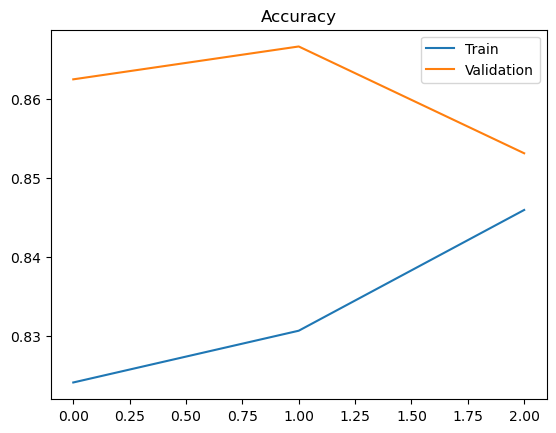

In [11]:
# Plot accuracy
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy")
plt.show()